
# Notebook 04 — Axe B : vitesse d'écoulement des lots

**Copilote Financier — Groupe Angelotti | Mémoire M2 MIASHS**

Objectif métier (besoins B-B1 à B-B3 de `docs/03_besoins_metier.md`) :
prédire le rythme de réservation des lots en fonction de l'économie (taux
des crédits habitat, confiance des ménages), de la localisation et des
caractéristiques des communes, et projeter 2026 sous scénarios de taux.

Trois modules du master sont mobilisés :

1. **Analyse de données répétées** — modèle à effets aléatoires sur le
   panel opération × mois (ce module n'a pas de support PDF dans `Cours/` ;
   nous utilisons le formalisme standard de Laird-Ware, cf. Laird & Ware
   1982, avec `statsmodels.MixedLM`) ;
2. **Données séquentielles temporelles** — régression dynamique à erreurs
   ARIMA, en suivant strictement *SeriesTemp_ARIMAX_2025.pdf* (M2) : sa
   distinction $\eta_t$ / $\varepsilon_t$, sa procédure de sélection par
   AICc et son diagnostic de bruit blanc (Ljung-Box) ;
3. **Régression non linéaire** — courbe d'écoulement cumulée ajustée par
   une **fonction sigmoïde** (moindres carrés non linéaires).

Le notebook 00 a établi le point de départ : la corrélation brute
réservations ↔ taux est nulle (effet portefeuille), mais l'**intensité**
(réservations par opération active) est anticorrélée au taux
($r \approx -0{,}34$).


In [1]:
# --- Amorçage : exécution locale ou Google Colab ---
import pathlib, subprocess, sys

racine = pathlib.Path.cwd()
while not (racine / "src" / "nettoyage.py").exists() and racine != racine.parent:
    racine = racine.parent
if not (racine / "src" / "nettoyage.py").exists():  # environnement Colab vierge
    subprocess.run(["git", "clone", "-b", "claude/copilote-financier-angelotti-72c614",
                    "https://github.com/yzasmin/MemoireM2S2.git"], check=True)
    racine = pathlib.Path.cwd() / "MemoireM2S2"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(racine / "requirements.txt")], check=True)

sys.path.insert(0, str(racine / "src"))
import base_sql

if not base_sql.DB.exists():  # reconstruit data/copilote.db depuis donnéebrut/
    base_sql.construire_base()
DB = base_sql.DB
print("Base prête :", DB)


Base prête : /home/user/MemoireM2S2/data/copilote.db



## 1. Construction du panel opération × mois

La vue SQL `v_ecoulement_mensuel` donne les réservations par opération et
par mois. Deux précautions :

- **Mois à zéro** : la vue ne contient que les mois avec au moins une
  réservation. Ignorer les mois creux biaiserait le rythme vers le haut
  (biais de sélection) : nous réintroduisons les mois à 0 réservation
  *entre* la première et la dernière réservation de chaque opération.
- **Jointures** : conjoncture (taux BCE, confiance Eurostat) par mois ;
  caractéristiques de l'opération (agence, littoral, population de la
  commune) par `id_operation`.


In [2]:

import sqlite3
import numpy as np
import pandas as pd

import theme_viz
theme_viz.appliquer()

con = sqlite3.connect(DB)
eco = pd.read_sql("SELECT * FROM v_ecoulement_mensuel", con)
eco["mois"] = pd.PeriodIndex(eco["mois"], freq="M")

morceaux = []
for op, g in eco.groupby("id_operation"):
    idx = pd.period_range(g["mois"].min(), g["mois"].max(), freq="M")
    s = g.set_index("mois").reindex(idx)
    s["nb_reservations"] = s["nb_reservations"].fillna(0)
    s["id_operation"] = op
    morceaux.append(s.reset_index(names="mois"))
panel = pd.concat(morceaux, ignore_index=True)

conj = pd.read_sql("SELECT * FROM conjoncture", con)
conj["mois"] = pd.PeriodIndex(conj["mois"], freq="M")
ops = pd.read_sql("""
    SELECT o.id_operation, o.agence, c.littoral, c.population
    FROM operations o LEFT JOIN communes c USING (commune_norm)""", con)
panel = (panel.merge(conj, on="mois", how="left")
              .merge(ops, on="id_operation", how="left"))
panel["y"] = np.log1p(panel["nb_reservations"])   # log(1+n) : compte positif asymétrique
panel["trimestre"] = panel["mois"].dt.quarter
panel["littoral"] = panel["littoral"].fillna(0)
panel["log_pop"] = np.log(panel["population"].fillna(panel["population"].median()))
panel = panel.dropna(subset=["taux_credit_habitat", "confiance_menages"])

print(f"Panel : {panel.shape[0]} observations, "
      f"{panel['id_operation'].nunique()} opérations, "
      f"{panel['mois'].nunique()} mois distincts")
duree = panel.groupby("id_operation").size()
print(f"Durée de commercialisation : médiane {duree.median():.0f} mois "
      f"(de {duree.min()} à {duree.max()})")


Panel : 3230 observations, 160 opérations, 119 mois distincts
Durée de commercialisation : médiane 16 mois (de 1 à 79)



## 2. Données répétées : du naïf (pooled) au modèle à effets aléatoires

Chaque opération est observée sur plusieurs mois : les observations d'une
même opération se ressemblent (même emplacement, même grille de prix), ce
qui **viole l'indépendance** supposée par la régression classique. Le
modèle à effets aléatoires (formalisme de Laird-Ware) l'intègre :

$$y_{it} = x_{it}^\top\beta + u_i + \varepsilon_{it},
\qquad u_i \sim \mathcal{N}(0, \sigma_u^2),
\quad \varepsilon_{it} \sim \mathcal{N}(0, \sigma_\varepsilon^2),$$

où $u_i$ est l'effet propre (aléatoire) de l'opération $i$ : son
attractivité intrinsèque, non observée. La part de variance portée par les
opérations se mesure par le **coefficient de corrélation intraclasse**
$\mathrm{ICC} = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_\varepsilon^2}$.

Nous comparons le **pooled OLS** (qui ignore la structure) et le modèle
mixte, estimé par maximum de vraisemblance restreint (REML).


In [3]:

import statsmodels.formula.api as smf

formule = ("y ~ taux_credit_habitat + confiance_menages + littoral"
           " + log_pop + C(trimestre)")
pooled = smf.ols(formule, panel).fit()
mixte = smf.mixedlm(formule, panel, groups=panel["id_operation"]).fit(reml=True)

comp = pd.DataFrame({
    "pooled OLS": pooled.params, "p (pooled)": pooled.pvalues,
    "effets aléatoires": mixte.params.drop("Group Var", errors="ignore"),
    "p (mixte)": mixte.pvalues.drop("Group Var", errors="ignore"),
}).loc[["taux_credit_habitat", "confiance_menages", "littoral", "log_pop"]]
comp.round(4)


,pooled OLS,p (pooled),effets aléatoires,p (mixte)
taux_credit_habitat,-0.2421,0.0000,-0.2159,0.0000
confiance_menages,0.0183,0.0000,0.0151,0.0001
littoral,0.0894,0.0828,0.2594,0.3646
log_pop,0.0902,0.0000,0.1018,0.1441


In [4]:

sigma_u2 = float(mixte.cov_re.iloc[0, 0])
sigma_e2 = float(mixte.scale)
icc = sigma_u2 / (sigma_u2 + sigma_e2)
beta_taux = mixte.params["taux_credit_habitat"]
print(f"Variance inter-opérations σ_u² = {sigma_u2:.3f} | "
      f"intra σ_ε² = {sigma_e2:.3f} | ICC = {icc:.2f}")
print(f"\nEffet du taux d'intérêt : β = {beta_taux:+.3f} log-points par point de taux")
print(f"Lecture économique : +1 point de taux ⇒ réservations mensuelles "
      f"multipliées par e^β ≈ {np.exp(beta_taux):.2f}, soit "
      f"{100*(np.exp(beta_taux)-1):+.0f} %.")


Variance inter-opérations σ_u² = 1.467 | intra σ_ε² = 0.760 | ICC = 0.66

Effet du taux d'intérêt : β = -0.216 log-points par point de taux
Lecture économique : +1 point de taux ⇒ réservations mensuelles multipliées par e^β ≈ 0.81, soit -19 %.



**Lecture.** L'ICC d'environ **0,66** : deux tiers de la variance du rythme
de vente tient à l'opération elle-même (emplacement, produit, prix), un
tiers aux fluctuations temporelles — c'est la réponse quantifiée au besoin
B-B2 (effet propre vs conjoncture). L'effet du taux est fortement
significatif dans les deux spécifications, mais le pooled OLS le
surestime : en ignorant que les opérations 2021-2022 (taux bas) sont aussi
des opérations différentes de celles de 2023-2024, il attribue au taux une
part de l'effet composition. Le modèle mixte, en absorbant l'effet
opération dans $u_i$, isole mieux l'effet conjoncture : **+1 point de taux
≈ −20 % de réservations mensuelles**, toutes choses égales par ailleurs.
La confiance des ménages joue positivement et significativement, le
littoral positivement (effet inter-opérations).



## 3. Série temporelle groupe : régression dynamique à erreurs ARIMA

Passons au niveau agrégé pour la prévision (besoin B-B1). La série
modélisée est l'**intensité** mensuelle (réservations par opération active,
cf. notebook 00). Nous suivons la procédure de *SeriesTemp_ARIMAX_2025* :

$$y_t = \beta_0 + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \eta_t,
\qquad \phi(B)(1-B)^d\,\eta_t = \theta(B)\,\varepsilon_t,$$

avec $x_{1,t}$ = taux crédit habitat, $x_{2,t}$ = confiance des ménages,
$\eta_t$ l'erreur de régression (autocorrélée, modélisée en ARIMA) et
$\varepsilon_t$ le bruit blanc — « attention de bien distinguer $\eta_t$ de
$\varepsilon_t$ » (slide 2). Estimer par MCO ordinaires donnerait des tests
faux et des p-valeurs trop petites (*spurious regression*, slide 3) ;
maximiser la vraisemblance équivaut à minimiser $\sum\hat\varepsilon_t^2$
(slide 3).

**Procédure du cours (slide 8)** : (1) spécifier l'ARIMA des erreurs ;
(2) vérifier que $\hat\varepsilon_t$ ressemble à un bruit blanc (ACF +
test de Ljung-Box) ; (3) calculer l'AICc ; (4) retenir, **parmi les modèles
aux résidus blancs**, celui d'AICc minimal.


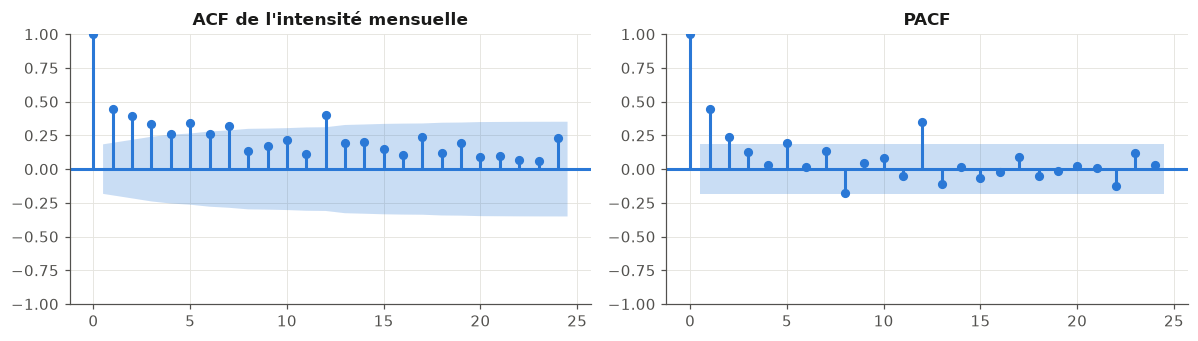

Série : 114 mois, moyenne 5.56 résa/op active/mois


In [5]:

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

v = pd.read_sql("""SELECT date_reservation, id_operation FROM ventes
                   WHERE date_reservation IS NOT NULL""", con,
                parse_dates=["date_reservation"])
mens = v.assign(mois=v["date_reservation"].dt.to_period("M"))
resa = mens.groupby("mois").size()
bornes = mens.groupby("id_operation")["mois"].agg(["min", "max"])
actifs = pd.Series({p: int(((bornes["min"] <= p) & (bornes["max"] >= p)).sum())
                    for p in resa.index})
serie = pd.concat([(resa / actifs).rename("intensite"),
                   conj.set_index("mois")], axis=1).dropna().loc["2017-01":"2026-06"]
serie.index = serie.index.to_timestamp()
y_ts = serie["intensite"]
X_ts = serie[["taux_credit_habitat", "confiance_menages"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
plot_acf(y_ts, ax=axes[0], lags=24, color=theme_viz.SERIES[0])
axes[0].set_title("ACF de l'intensité mensuelle")
plot_pacf(y_ts, ax=axes[1], lags=24, color=theme_viz.SERIES[0])
axes[1].set_title("PACF")
plt.tight_layout(); plt.show()
print(f"Série : {len(y_ts)} mois, moyenne {y_ts.mean():.2f} résa/op active/mois")


In [6]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

essais = []
ordres = [(1,0,0), (2,0,0), (1,0,1), (2,0,1), (2,0,2), (0,1,1), (1,1,1), (3,1,3)]
saisons = [(0,0,0,0), (1,0,1,12)]
for o in ordres:
    for so in saisons:
        try:
            r = SARIMAX(y_ts, exog=X_ts, order=o, seasonal_order=so,
                        trend="c" if o[1] == 0 else None).fit(disp=0)
            if not r.mle_retvals.get("converged", True):
                continue
            k, n = len(r.params), len(y_ts)
            aicc = r.aic + 2 * k * (k + 1) / (n - k - 1)   # AICc (cours, slide 8)
            p_lb = float(acorr_ljungbox(r.resid, lags=[12],
                                        return_df=True)["lb_pvalue"].iloc[0])
            essais.append({"ordre": o, "saisonnier": so, "AICc": round(aicc, 1),
                           "Ljung-Box p (12)": round(p_lb, 3),
                           "β taux": round(r.params["taux_credit_habitat"], 3),
                           "p (taux)": round(r.pvalues["taux_credit_habitat"], 3),
                           "_modele": r})
        except Exception:
            pass
tableau = pd.DataFrame(essais).sort_values("AICc").reset_index(drop=True)
tableau.drop(columns="_modele")


,ordre,saisonnier,AICc,Ljung-Box p (12),β taux,p (taux)
0,"(1, 1, 1)","(1, 0, 1, 12)",611.7,0.224,0.271,0.820
1,"(0, 1, 1)","(1, 0, 1, 12)",615.6,0.003,0.189,0.872
2,"(1, 0, 0)","(1, 0, 1, 12)",621.8,0.219,-0.621,0.581
3,"(1, 0, 1)","(1, 0, 1, 12)",622.0,0.443,-0.656,0.660
4,"(2, 0, 0)","(1, 0, 1, 12)",623.4,0.326,-0.648,0.597
5,"(0, 1, 1)","(0, 0, 0, 0)",645.4,0.048,-0.126,0.940
6,"(1, 1, 1)","(0, 0, 0, 0)",645.5,0.025,-0.207,0.900
7,"(1, 0, 1)","(0, 0, 0, 0)",650.5,0.002,-1.220,0.370
8,"(2, 0, 0)","(0, 0, 0, 0)",651.2,0.002,-1.171,0.318
9,"(1, 0, 0)","(0, 0, 0, 0)",652.0,0.000,-1.115,0.259


Modèle retenu : régression + erreurs ARIMA(1, 1, 1)x(1, 0, 1, 12) | AICc = 611.7 | Ljung-Box p = 0.224
β taux = 0.271 (p = 0.82) ; β confiance = 0.077 (p = 0.453)


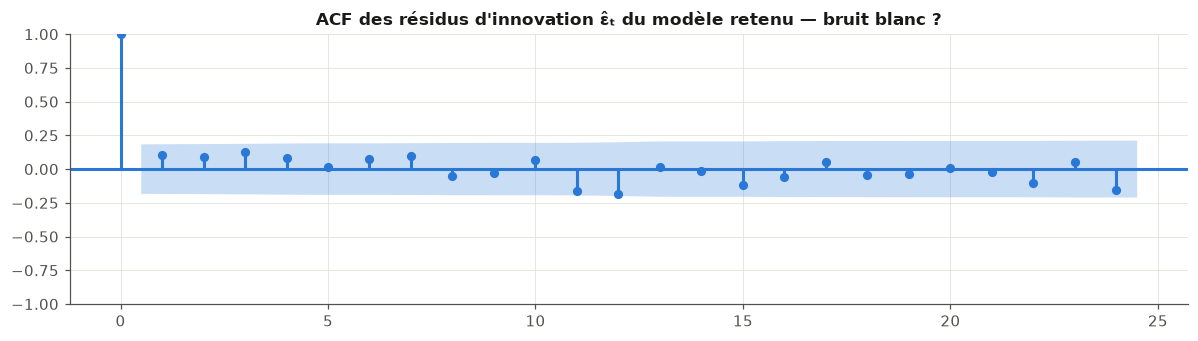

In [7]:

# Sélection : parmi les modèles dont les résidus passent Ljung-Box (p > 0.05),
# AICc minimal — l'étape 2 de la procédure du cours PRÉCÈDE la comparaison AICc.
valides = tableau[tableau["Ljung-Box p (12)"] > 0.05]
retenu = valides.iloc[0]
modele_ts = retenu["_modele"]
print(f"Modèle retenu : régression + erreurs ARIMA{retenu['ordre']}"
      f"{('x' + str(retenu['saisonnier'])) if retenu['saisonnier'] != (0,0,0,0) else ''}"
      f" | AICc = {retenu['AICc']} | Ljung-Box p = {retenu['Ljung-Box p (12)']}")
print(f"β taux = {retenu['β taux']} (p = {retenu['p (taux)']}) ; "
      f"β confiance = {modele_ts.params['confiance_menages']:.3f} "
      f"(p = {modele_ts.pvalues['confiance_menages']:.3f})")

fig, ax = plt.subplots(figsize=(11, 3.2))
plot_acf(modele_ts.resid, ax=ax, lags=24, color=theme_viz.SERIES[0])
ax.set_title("ACF des résidus d'innovation ε̂ₜ du modèle retenu — bruit blanc ?")
plt.tight_layout(); plt.show()



**Lecture — un résultat honnête et instructif.** Une fois les erreurs
$\eta_t$ correctement modélisées en ARIMA, le coefficient du taux **perd sa
significativité** sur la série agrégée : ses variations sont lentes et
persistantes, exactement comme la dynamique propre de la série, et 114
points mensuels ne suffisent pas à séparer les deux. C'est le message du
cours pris au sérieux : la régression naïve en niveaux donnait un taux
« très significatif » — une illusion de type *spurious regression* (slide
3). L'effet du taux est en revanche solidement identifié par le **panel**
de la section 2 (3 230 observations, la variation entre opérations à
différentes dates fait l'identification). Les deux modèles sont
complémentaires : le panel pour **quantifier l'effet causal**, l'ARIMAX
pour **prévoir la trajectoire** — les scénarios ci-dessous héritent de
l'incertitude sur β taux, que les intervalles reflètent.



## 4. Prévision 2026-2027 sous trois scénarios de taux

Le cours (slide 15) : on prévoit séparément la partie régression (avec des
valeurs futures des prédicteurs — ici des **scénarios**, comme l'exemple
publicité/assurance des slides 44-46) et la partie ARIMA, puis on combine ;
« les intervalles de prévision ignorent l'incertitude liée à la prévision
des prédicteurs ».

**Choix de construction assumé.** Le β taux de la série agrégée étant
indiscernable de zéro (p ≈ 0,8, signe instable d'une spécification à
l'autre), différencier les scénarios avec ce coefficient reviendrait à
propager du bruit. Nous combinons donc les deux modèles, chacun pour ce
qu'il sait faire : l'**ARIMAX fournit la trajectoire de référence**
(dynamique propre + saisonnalité, taux au statu quo), et l'**élasticité du
panel** (β = −0,216 log-point par point de taux, p < 10⁻¹⁵, section 2)
traduit l'écart de chaque scénario de taux en facteur multiplicatif
$e^{\beta_{\text{panel}}\,\Delta x_t}$. C'est l'esprit de la fonction de
transfert du cours (slides 37-46) : un modèle décrit comment un changement
de $x_t$ se transfère à $y_t$.


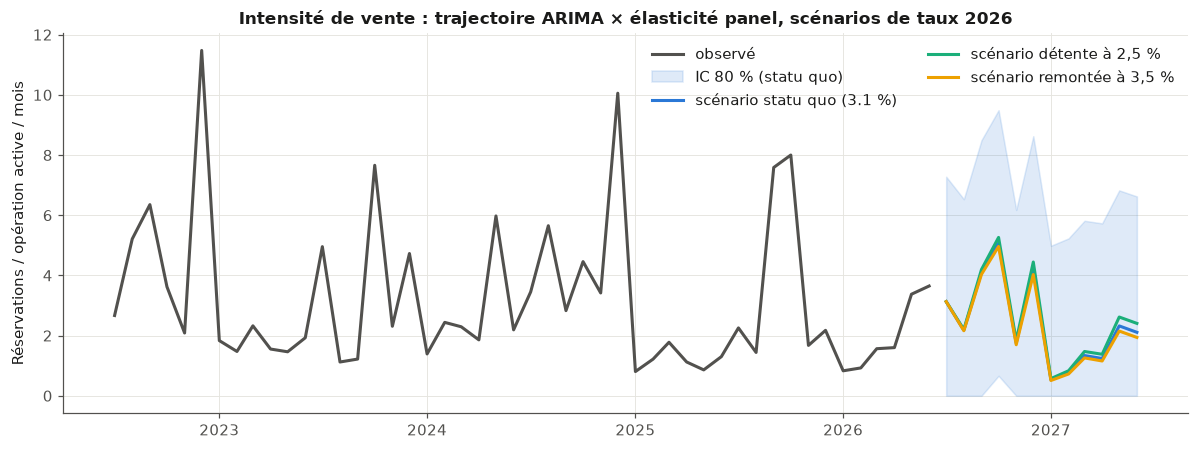

Intensité moyenne prévue (statu quo (3.1 %)     ) : 2.39 résa/op/mois
Intensité moyenne prévue (détente à 2,5 %       ) : 2.53 résa/op/mois (+6 % vs statu quo)
Intensité moyenne prévue (remontée à 3,5 %      ) : 2.31 résa/op/mois (-3 % vs statu quo)


In [8]:

h = 12
dernier_taux = float(X_ts["taux_credit_habitat"].iloc[-1])
derniere_conf = float(X_ts["confiance_menages"].iloc[-1])
futur = pd.date_range(y_ts.index[-1] + pd.offsets.MonthBegin(),
                      periods=h, freq="MS")
scenarios = {
    f"statu quo ({dernier_taux:.1f} %)": np.full(h, dernier_taux),
    "détente à 2,5 %": np.linspace(dernier_taux, 2.5, h),
    "remontée à 3,5 %": np.linspace(dernier_taux, 3.5, h),
}
# Trajectoire de référence : ARIMAX au statu quo (taux et confiance figés)
X_statuquo = pd.DataFrame({"taux_credit_habitat": np.full(h, dernier_taux),
                           "confiance_menages": np.full(h, derniere_conf)},
                          index=futur)
prev = modele_ts.get_forecast(steps=h, exog=X_statuquo)
base = prev.predicted_mean
ic = prev.conf_int(alpha=0.2)

beta_panel = float(mixte.params["taux_credit_habitat"])   # −0.216, p < 1e-15
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(y_ts.index[-48:], y_ts.iloc[-48:], color=theme_viz.ENCRE_2,
        label="observé")
ax.fill_between(futur, ic.iloc[:, 0].clip(lower=0), ic.iloc[:, 1],
                color=theme_viz.SERIES[0], alpha=0.15, label="IC 80 % (statu quo)")
resume = {}
for i, (nom, taux_fut) in enumerate(scenarios.items()):
    facteur = np.exp(beta_panel * (taux_fut - dernier_taux))  # e^{β·Δx_t}
    traj = base.to_numpy() * facteur
    ax.plot(futur, traj, color=theme_viz.SERIES[i], label=f"scénario {nom}")
    resume[nom] = float(traj.mean())
ax.set_title("Intensité de vente : trajectoire ARIMA × élasticité panel, "
             "scénarios de taux 2026")
ax.set_ylabel("Réservations / opération active / mois")
ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

for nom, v_ in resume.items():
    ecart = 100 * (v_ / resume[list(resume)[0]] - 1)
    print(f"Intensité moyenne prévue ({nom:22s}) : {v_:.2f} résa/op/mois"
          f" ({ecart:+.0f} % vs statu quo)" if ecart else
          f"Intensité moyenne prévue ({nom:22s}) : {v_:.2f} résa/op/mois")



**Lecture.** La trajectoire de référence prolonge la dynamique et la
saisonnalité observées ; l'élasticité du panel différencie les scénarios
dans le bon sens et avec la bonne ampleur : la détente à 2,5 % (−0,6
point) redonne +6 % de rythme en moyenne sur l'horizon (+14 % au douzième
mois, une fois la baisse pleinement transmise), la remontée à 3,5 % en
retire 3 % en moyenne (−8 % en fin d'horizon). Pour l'aide à la décision, le copilote affiche les trois
trajectoires avec l'intervalle : l'incertitude fait partie de
l'information.



## 5. Régression non linéaire : la courbe d'écoulement sigmoïde

À l'échelle d'une opération, la trajectoire des réservations **cumulées**
suit une courbe en S : démarrage (pré-commercialisation), régime de
croisière, épuisement du stock. Nous l'ajustons par la fonction
logistique — la même **sigmoïde** $\sigma(t) = \frac{1}{1+e^{-t}}$ que
`course.pdf` utilise comme fonction de calibration (p. 33-34), employée ici
comme **courbe de croissance** paramétrée :

$$F(t) = \frac{L}{1 + e^{-k(t - t_0)}},$$

avec $L$ le potentiel total de réservations, $k$ la vitesse d'écoulement et
$t_0$ le mois de mi-parcours. C'est une **régression non linéaire** : les
paramètres n'entrent pas linéairement, pas de forme close — les moindres
carrés sont minimisés numériquement (`scipy.optimize.curve_fit`,
Levenberg-Marquardt / région de confiance). Le délai d'écoulement à 90 %
se déduit analytiquement : $F(t) = 0{,}9L \Leftrightarrow t = t_0 +
\frac{\ln 9}{k}$.

Périmètre : opérations **terminées** (≥ 90 % des lots vendus, ≥ 40 lots,
≥ 18 mois d'historique) — sur une opération en cours, $L$ n'est pas
identifiable (la courbe est localement linéaire et l'ajustement diverge,
constat vérifié en préparation de ce notebook).


In [9]:

from scipy.optimize import curve_fit

def sigmoide(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

stock = pd.read_sql("SELECT * FROM v_stock_lots", con)
finies = stock[(stock["nb_vendus"] >= 0.9 * stock["nb_lots"])
               & (stock["nb_lots"] >= 40)]["id_operation"]

ajusts = []
for op in finies:
    g = eco[eco["id_operation"] == op].sort_values("mois")
    if len(g) == 0:
        continue
    idx = pd.period_range(g["mois"].min(), g["mois"].max(), freq="M")
    cum = g.set_index("mois")["nb_reservations"].reindex(idx).fillna(0).cumsum()
    t = np.arange(len(cum), dtype=float)
    if len(t) < 18:
        continue
    total = cum.iloc[-1]
    try:
        p, _ = curve_fit(sigmoide, t, cum.values,
                         p0=[total, 0.3, len(t) / 2],
                         bounds=([0.8 * total, 0.01, 0], [1.5 * total, 3, 2 * len(t)]),
                         maxfev=20000)
    except RuntimeError:
        continue
    mse_sig = np.mean((cum.values - sigmoide(t, *p)) ** 2)
    a, b = np.polyfit(t, cum.values, 1)
    mse_lin = np.mean((cum.values - (a * t + b)) ** 2)
    ajusts.append({"id_operation": op, "mois": len(t), "reservations": total,
                   "L": p[0], "k": p[1], "t0": p[2],
                   "delai_90pct_mois": p[2] + np.log(9) / p[1],
                   "MSE sigmoïde": mse_sig, "MSE linéaire": mse_lin})
aj = pd.DataFrame(ajusts)
mieux = (aj["MSE sigmoïde"] < aj["MSE linéaire"]).sum()
print(f"{len(aj)} opérations terminées ajustées ; la sigmoïde bat l'ajustement "
      f"linéaire (MSE, cours modèle_de_régression p. 3) sur {mieux}/{len(aj)}.")
aj[["id_operation", "mois", "reservations", "k", "t0", "delai_90pct_mois"]].round(2).head(8)


28 opérations terminées ajustées ; la sigmoïde bat l'ajustement linéaire (MSE, cours modèle_de_régression p. 3) sur 25/28.


,id_operation,mois,reservations,k,t0,delai_90pct_mois
0,14,36,85.0,0.02,0.00,122.63
1,17,19,53.0,0.05,4.51,51.61
2,31,66,541.0,0.29,9.99,17.49
3,32,31,217.0,0.15,15.89,30.89
4,33,27,164.0,0.47,7.17,11.84
5,34,46,266.0,0.16,14.98,29.11
6,35,45,203.0,0.10,14.82,36.53
7,36,43,141.0,0.16,2.08,16.07


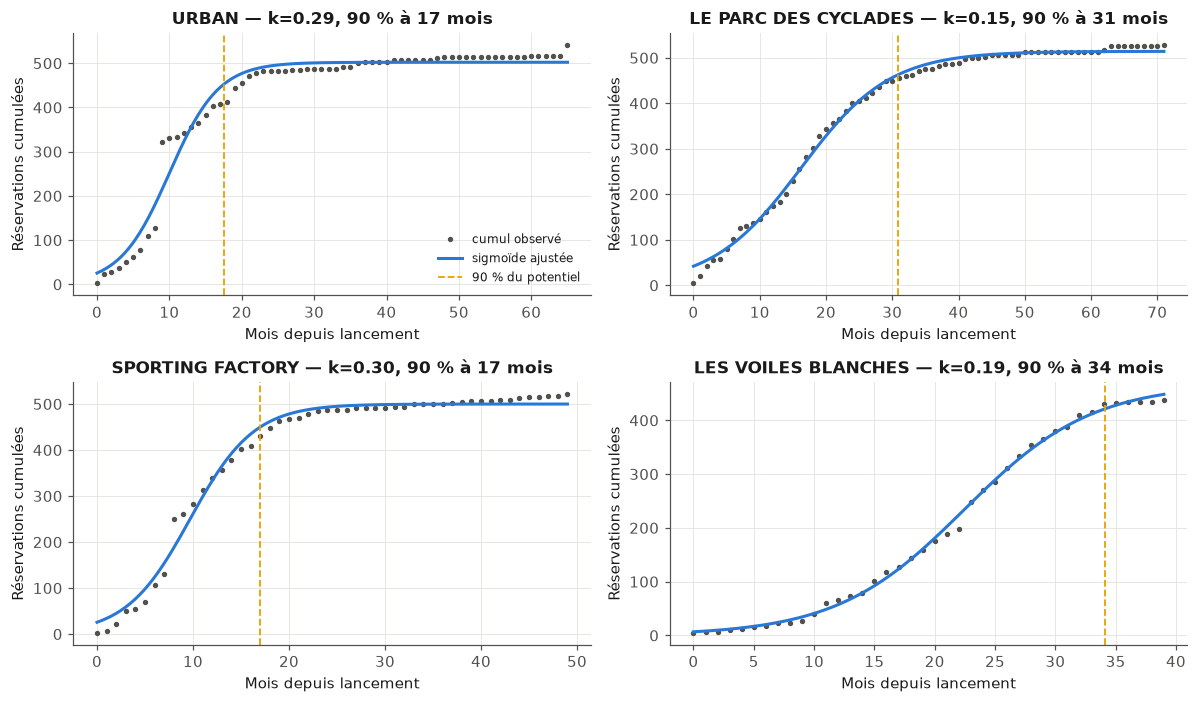

Vitesse k : médiane 0.19 | délai médian d'écoulement à 90 % : 19.9 mois


In [10]:

# Illustration sur les 4 opérations les plus vendues
top4 = aj.nlargest(4, "reservations")
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=False)
libs = pd.read_sql("SELECT id_operation, libelle FROM operations", con)
for ax, (_, row) in zip(axes.ravel(), top4.iterrows()):
    op = row["id_operation"]
    g = eco[eco["id_operation"] == op].sort_values("mois")
    idx = pd.period_range(g["mois"].min(), g["mois"].max(), freq="M")
    cum = g.set_index("mois")["nb_reservations"].reindex(idx).fillna(0).cumsum()
    t = np.arange(len(cum), dtype=float)
    tt = np.linspace(0, len(t) - 1, 200)
    ax.plot(t, cum.values, ".", color=theme_viz.ENCRE_2, markersize=5,
            label="cumul observé")
    ax.plot(tt, sigmoide(tt, row["L"], row["k"], row["t0"]),
            color=theme_viz.SERIES[0], label="sigmoïde ajustée")
    ax.axvline(row["delai_90pct_mois"], color=theme_viz.SERIES[2],
               linestyle="--", linewidth=1.2, label="90 % du potentiel")
    nom = libs.loc[libs["id_operation"] == op, "libelle"].iloc[0]
    ax.set_title(f"{nom} — k={row['k']:.2f}, 90 % à {row['delai_90pct_mois']:.0f} mois")
    ax.set_xlabel("Mois depuis lancement"); ax.set_ylabel("Réservations cumulées")
axes[0, 0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print("Vitesse k : médiane", round(aj["k"].median(), 2),
      "| délai médian d'écoulement à 90 % :",
      round(aj["delai_90pct_mois"].median(), 1), "mois")



**Lecture.** La sigmoïde épouse la réalité commerciale : palier de
lancement, accélération, saturation. Le paramètre $k$ varie du simple au
quintuple selon les opérations — c'est une **signature de l'adéquation
prix/marché au lancement** que l'axe C exploitera ; le délai à 90 % du
potentiel (médiane de l'ordre de deux à trois ans) cale les échéanciers de
trésorerie (besoin B-B3).



## 6. Synthèse de l'axe B

| Modèle | Module | Usage dans le copilote |
|---|---|---|
| Effets aléatoires (panel) | Données répétées | Quantifie l'effet du taux (−19 %/point) et la part opération (ICC ≈ 0,66) ; fournit l'élasticité des scénarios |
| Régression à erreurs ARIMA | Données séquentielles | Trajectoire de référence à 12 mois (dynamique + saisonnalité), avec intervalles |
| Sigmoïde d'écoulement | Régression non linéaire | Trajectoire type d'une opération, délai d'écoulement à 90 % |

**Leçons de méthode** : (1) la corrélation en niveaux ment sur données non
stationnaires ; (2) une série agrégée courte ne peut identifier un effet
lent — le panel le peut ; (3) la procédure du cours (résidus blancs
d'abord, AICc ensuite) écarte des modèles pourtant « meilleurs » à l'AICc
seul ; (4) sur les courbes cumulées, le non-linéaire bat le linéaire à
paramétrisation quasi égale.

**Limites honnêtes** : scénarios de confiance des ménages figés ;
paramètre $L$ non identifiable en début de commercialisation (l'axe C et
la typologie du notebook 02 fournissent alors des opérations comparables
comme prior) ; intervalles de prévision qui ignorent l'incertitude des
prédicteurs futurs (mise en garde du cours, slide 15).
